In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.extras import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore")

# EDA

In [4]:
df=pd.read_csv("insurance.csv")


### About Dataset

#### Content of Columns

_**age**: age of primary beneficiary_

_**sex**: insurance contractor gender, female, male_

_**bmi**: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9_

_**children**: Number of children covered by health insurance / Number of dependents_

_**smoker**: Smoking_

_**region**: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest._

_**charges**: Individual medical costs billed by health insurance_

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

<Axes: xlabel='age', ylabel='charges'>

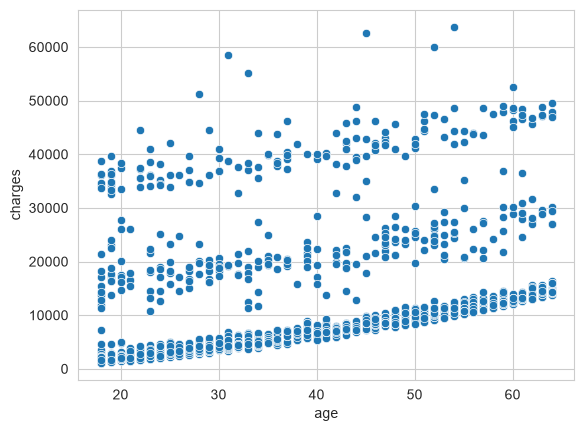

In [12]:
sns.scatterplot(x="age",y='charges',data=df)

<Axes: xlabel='sex', ylabel='count'>

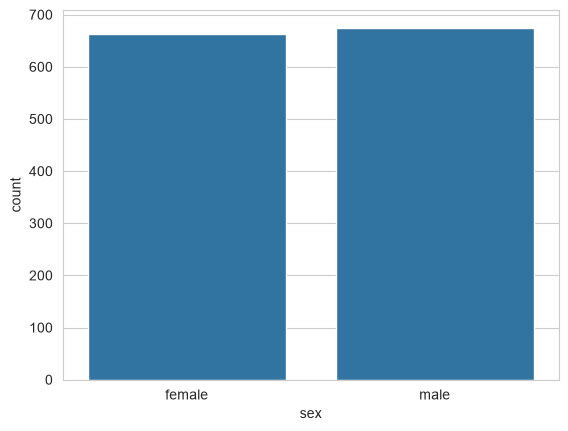

In [13]:
sns.countplot(x='sex',data=df)

<Axes: xlabel='region', ylabel='count'>

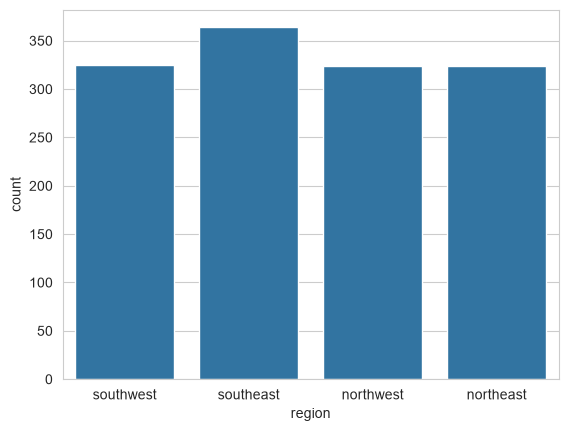

In [14]:
sns.countplot(x='region',data=df)

<Axes: xlabel='age', ylabel='Count'>

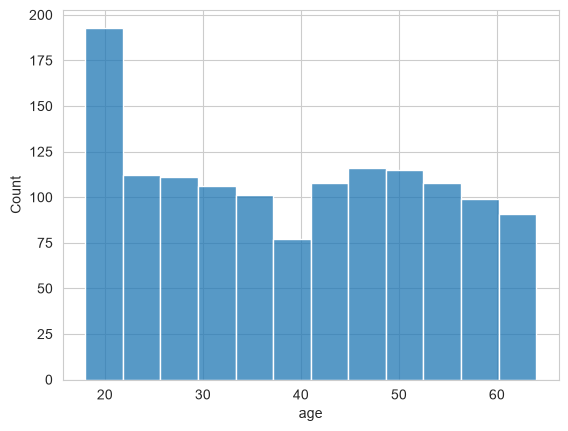

In [15]:
sns.histplot(x='age',data=df)

<Axes: xlabel='charges', ylabel='Count'>

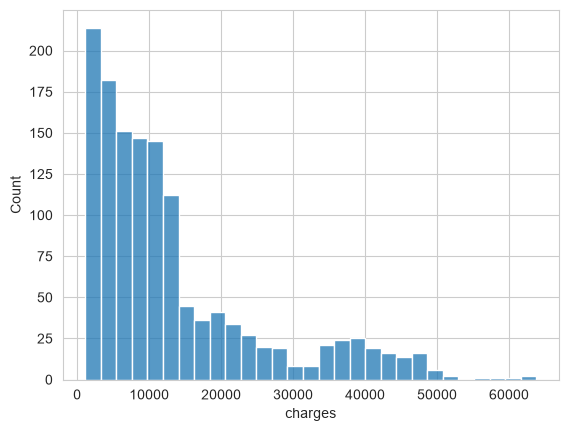

In [16]:
sns.histplot(x='charges',data=df)

<Axes: xlabel='sex', ylabel='charges'>

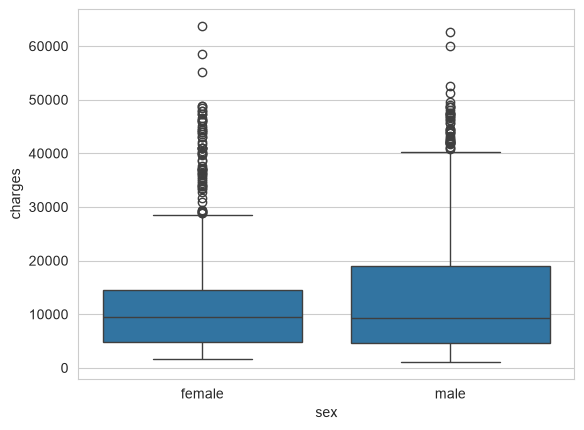

In [17]:
sns.boxplot(x='sex',y='charges',data=df)


<Axes: xlabel='bmi', ylabel='charges'>

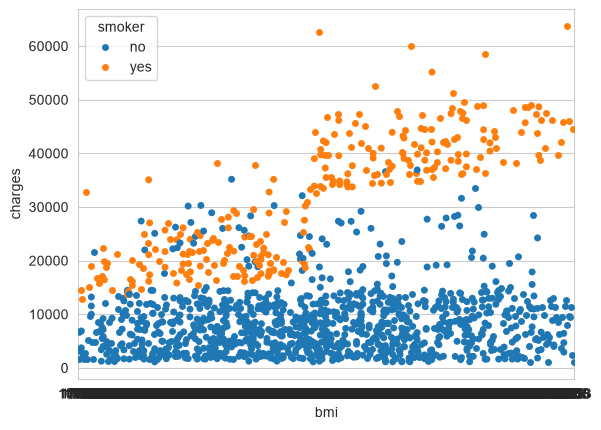

In [18]:
sns.stripplot(x="bmi",y="charges",hue="smoker",dodge='True',data=df)

In [19]:
df.bmi.value_counts()


bmi
32.30    13
28.31     9
28.88     8
34.10     8
30.80     8
         ..
53.13     1
39.71     1
32.87     1
44.70     1
30.97     1
Name: count, Length: 548, dtype: int64

<Axes: xlabel='bmi'>

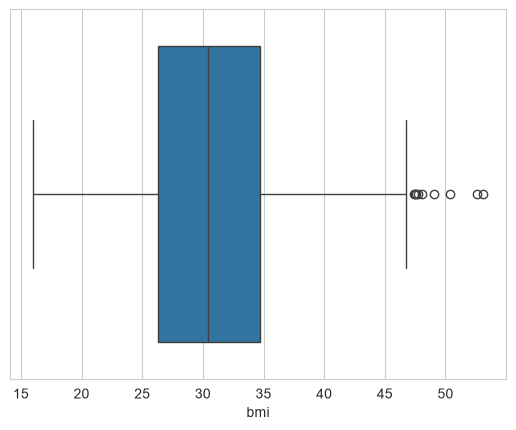

In [20]:
sns.boxplot(x='bmi',data=df)

### preprocessing

In [21]:
Q1=df['charges'].quantile(0.25)
Q3=df['charges'].quantile(0.75)
threshold=1.5
IQR= Q3 - Q1

lower=Q1-threshold*IQR
upper=Q3+threshold*IQR

df=df[(df['charges']>=lower) & (df['charges']<=upper)]

<Axes: xlabel='sex', ylabel='charges'>

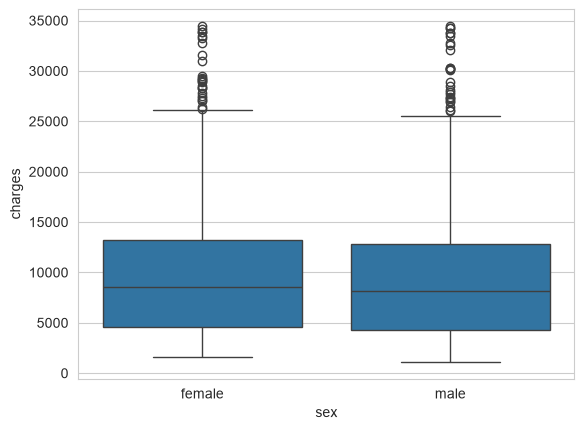

In [22]:
sns.boxplot(x='sex',y='charges',data=df)


In [23]:
Q1=df['bmi'].quantile(0.25)
Q3=df['bmi'].quantile(0.75)
threshold=1.5
IQR= Q3 - Q1

lower=Q1-threshold*IQR
upper=Q3+threshold*IQR

df=df[(df['bmi']>=lower) & (df['bmi']<=upper)]

<Axes: xlabel='bmi'>

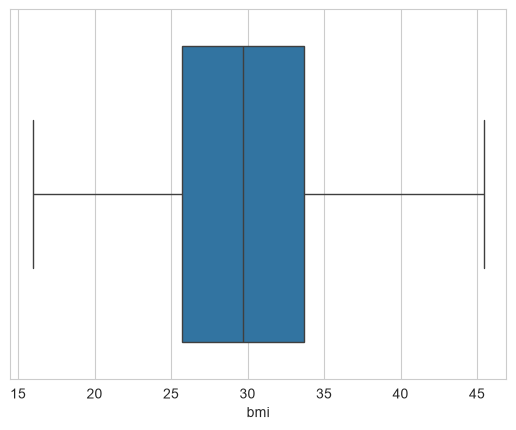

In [24]:
sns.boxplot(x='bmi',data=df)

In [25]:
df.bmi.value_counts()

bmi
32.30    12
28.31     9
28.88     8
34.10     7
27.36     7
         ..
42.90     1
39.71     1
32.87     1
44.70     1
30.97     1
Name: count, Length: 507, dtype: int64

### split data

In [26]:
x=df.drop("charges",axis=1)
y=df['charges']

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=22)

### encode catgorical data

In [28]:

x_train['smoker_num'] = x_train['smoker'].map({'yes': 1, 'no': 0})
x_test['smoker_num'] = x_test['smoker'].map({'yes': 1, 'no': 0})


x_train['bmi_smoker'] = x_train['bmi'] * x_train['smoker_num']
x_test['bmi_smoker'] = x_test['bmi'] * x_test['smoker_num']

In [29]:
x_train=x_train.drop("smoker",axis=1)
x_test=x_test.drop("smoker",axis=1)

In [30]:
encoder= OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False)

In [31]:
categorical_cols = ['sex','region']
numerical_cols=['age','bmi','children','bmi_smoker']

In [32]:
x_train_cat=encoder.fit_transform(x_train[categorical_cols])
x_test_cat=encoder.transform(x_test[categorical_cols])


In [33]:
x_train_final=np.hstack([x_train[numerical_cols].values,x_train_cat])
x_test_final=np.hstack([x_test[numerical_cols].values,x_test_cat])

### Calling model

In [34]:
lr=LinearRegression()


In [35]:
lr.fit(x_train_final,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 249.84, 43.13, 427.43,...,-175.42,-785.37,-823.29]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2829
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[407.1 ,251.73,155.92,..., 14.35, 13.82, 7.09]"


In [36]:
lr.coef_

array([ 249.84327744,   43.13064979,  427.42967705,  565.29057405,
       -245.29519316, -175.42191295, -785.36999684, -823.28512076])

In [37]:
lr.intercept_

np.float64(-2829.1327635126363)

In [38]:
y_pred=lr.predict(x_test_final)

In [39]:
r2_score(y_test,y_pred)

0.5345926147293456

In [40]:
mean_squared_error(y_test,y_pred)

25204193.835180797

In [41]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Average Percentage Error: {mape * 100:.1f}%")

Average Percentage Error: 28.2%


In [42]:
import joblib

joblib.dump(lr, 'linear_regression_model.pkl')
joblib.dump(encoder, 'onehot_encoder.pkl')

['onehot_encoder.pkl']

In [43]:
print(numerical_cols)
print(encoder.get_feature_names_out())
print(lr.coef_)
print(lr.intercept_)

['age', 'bmi', 'children', 'bmi_smoker']
['sex_male' 'region_northwest' 'region_southeast' 'region_southwest']
[ 249.84327744   43.13064979  427.42967705  565.29057405 -245.29519316
 -175.42191295 -785.36999684 -823.28512076]
-2829.1327635126363
